#### Importing necessary libraries:
• Pandas to process data\
• Matplotlib and seaborn for plots

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Importing data
Dataset file has been imported from drive, then stored as a Pandas data frame.

In [ ]:
file_path = '/content/drive/MyDrive/Data/PIANO.xlsx'
try:
    df_drive = pd.read_excel(file_path, header = 1)
except Exception as e:
    print(f"An error occurred while loading the file: {e}")
df_drive

,Dataset,PDB,Uniprots,Partners,Chain,Residue index,Wild-type,Mutant,ΔΔG (kcal/mol)
0,Training,3K2M,P00519,A_D,D,87,Y,A,4.000
1,Training,3K2M,P00519,A_D,D,36,Y,A,3.700
2,Training,3K2M,P00519,A_D,D,80,W,A,4.000
3,Training,3K2M,P00519,A_D,D,35,Y,A,1.000
4,Training,3K2M,P00519,A_D,D,88,M,A,4.000
...,...,...,...,...,...,...,...,...,...
4305,Benchmark test,1A4Y,"P03950,P13489",A_B,B,108,E,A,-0.323
4306,Benchmark test,1A4Y,"P03950,P13489",A_B,A,435,D,A,3.480
4307,Benchmark test,1A4Y,"P03950,P13489",A_B,A,437,Y,A,0.836
4308,Benchmark test,1A4Y,"P03950,P13489",A_B,A,457,R,A,-0.224


#### Number of protein complexes in the dataset
To derive the amount of complexes in the dataset and the number of occurrences of each complex, the Pandas method <.value_counts()> was used on the column reporting the PDB IDs and stored in a dictionary using the method <to_dict()>.

In [ ]:
pdb_occurrences = df_drive['PDB'].value_counts().to_dict()
print(pdb_occurrences)
print(len(pdb_occurrences))

{'3BT1': 240, '3SGB': 191, '1CHO': 191, '1R0R': 191, '1PPF': 190, '1A22': 140, '1DAN': 89, '1AO7': 86, '3S9D': 81, '3HFM': 73, '1MHP': 68, '3BN9': 60, '1JTG': 58, '1GC1': 54, '3NPS': 54, '1C4Z': 48, '1EMV': 46, '1VFB': 45, '1BP3': 45, '2JEL': 43, '1JRH': 43, '3NGB': 41, '2NYY': 40, '1OGA': 40, '1LFD': 38, '1JTD': 36, '1IAR': 36, '4RS1': 36, '4P23': 35, '4P5T': 35, '3C60': 35, '4NKQ': 34, '3BE1': 34, '3BDY': 34, '1A4Y': 32, '1CBW': 31, '1BRS': 30, '2NZ9': 29, '1BJ1': 29, '4G0N': 29, '3SE8': 28, '2G2U': 27, '1EAW': 27, '1KTZ': 27, '2BNR': 26, '2WPT': 26, '1DVF': 26, '1MI5': 25, '3QHY': 25, '3SE9': 25, '3SE4': 25, '3QIB': 22, '3SZK': 21, '1DQJ': 21, '1B41': 20, '1FSS': 20, '2AK4': 20, '1CZ8': 19, '1FFW': 19, '1K8R': 19, '2FTL': 19, '5C6T': 18, '1XD3': 18, '1FC2': 18, '4PWX': 18, '3M62': 18, '1TM1': 17, '1Z7X': 17, '3SE3': 17, '1AK4': 16, '2J0T': 16, '1E50': 16, '1YY9': 16, '5M2O': 14, '2VLJ': 14, '3QDJ': 14, '3QDG': 14, '3BK3': 13, '1KNE': 13, '1C1Y': 13, '5F4E': 13, '1N8Z': 12, '1GUA': 1

In [16]:
pdb_chain_occurrences = {}

for pdb_id in df_drive['PDB'].unique():
    # Filter the DataFrame for the current PDB ID
    df_pdb = df_drive[df_drive['PDB'] == pdb_id]

    # Count occurrences of each 'Chain' within this PDB ID
    chain_counts = df_pdb['Chain'].value_counts().to_dict()

    # Store the result in the main dictionary
    pdb_chain_occurrences[pdb_id] = chain_counts

print(pdb_chain_occurrences)

{'3K2M': {'D': 7}, '5XCO': {'B': 7, 'A': 2}, '5UFE': {'A': 3, 'B': 1}, '5UFQ': {'A': 3}, '5TAR': {'B': 8}, '5M2O': {'B': 7, 'A': 7}, '5K39': {'B': 5}, '5F4E': {'A': 7, 'B': 6}, '5E6P': {'B': 4, 'A': 3}, '5CXB': {'B': 5}, '5CYK': {'B': 2}, '5C6T': {'A': 10, 'H': 6, 'L': 2}, '4ZS6': {'A': 2}, '4YH7': {'A': 3, 'B': 2}, '4YFD': {'B': 3, 'A': 3}, '4YEB': {'B': 2, 'A': 2}, '4Y61': {'B': 1, 'A': 1}, '4X4M': {'E': 6}, '4U6H': {'E': 2}, '4RS1': {'A': 25, 'B': 11}, '4RA0': {'C': 2}, '4PWX': {'C': 10, 'B': 5, 'A': 3}, '4P5T': {'D': 24, 'C': 11}, '4P23': {'D': 24, 'C': 11}, '4OZG': {'H': 7, 'G': 2}, '4OFY': {'A': 7, 'D': 4}, '4NM8': {'B': 9}, '4NKQ': {'B': 26, 'C': 8}, '4N8V': {'G': 4}, '4MYW': {'B': 1}, '4MNQ': {'C': 2}, '4LRX': {'A': 1}, '4KRL': {'B': 1}, '4K71': {'A': 4, 'B': 2}, '4JPK': {'A': 8}, '4JGH': {'D': 1}, '4JFF': {'C': 6}, '4JEU': {'B': 4, 'A': 2}, '4J2L': {'A': 3, 'C': 2}, '4HSA': {'A': 4}, '4HRN': {'D': 4}, '4HFK': {'B': 7, 'D': 1}, '4GXU': {'A': 2}, '4GNK': {'B': 2, 'A': 1}, '4G2V'

To verify the amount of mutations is the one reported in the paper:

In [ ]:
total_occurrences = sum(pdb_occurrences.values())
print(f"The total sum of all PDB occurrences is: {total_occurrences}\nThis is the amount of single-point mutations.")

The total sum of all PDB occurrences is: 4310
This is the amount of single-point mutations.


#### Occurrences per PDB ID distribution plotted

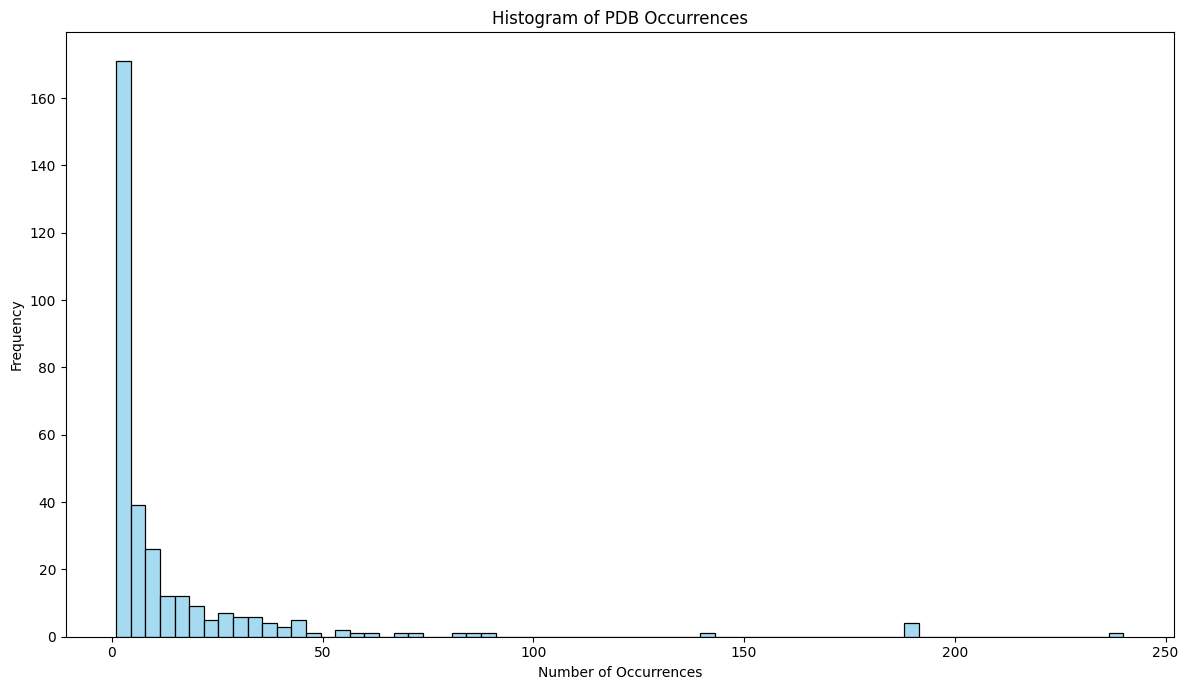

In [ ]:
pdb_counts_series = pd.Series(pdb_occurrences)

plt.figure(figsize=(12, 7))
sns.histplot(pdb_counts_series.values, fill=True, color='skyblue', kde=False)
plt.title('Histogram of PDB Occurrences')
plt.xlabel('Number of Occurrences')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

#### Dictionary where **key**: *PDB ID*; **value**: list of *Uniprot IDs*
Each list contains a single string of comma separated Uniprot IDs.

In [ ]:
pdb_to_uniprots = df_drive.groupby('PDB')['Uniprots'].apply(lambda x: x.unique().tolist()).to_dict()
print(pdb_to_uniprots)

{'1A22': ['P01241,P10912'], '1A4Y': ['P03950,P13489'], '1ACB': ['P01051,P00766'], '1AHW': ['P01837,P01868,X5J519,P13726'], '1AK4': ['P12497,P62937'], '1AO7': ['P14079,A0A075B6T6,A0A0K0K1A5,A0A5B9,P01848,P01850,P04439,P61769'], '1B2S': ['P00648,P11540'], '1B2U': ['P00648,P11540'], '1B3S': ['P00648,P11540'], '1B41': ['P0C1Z0,P22303'], '1BD2': ['P14079,P0C213,A0A0K0K1A5,A0A5B9,P01848,P04437,P04439,P61769'], '1BJ1': ['P15692'], '1BP3': ['P01241,P16471'], '1BRS': ['P00648,P11540'], '1C1Y': ['P04049,P62834'], '1C4Z': ['P68036,Q05086'], '1CBW': ['P00766,P00767,P00974'], '1CHO': ['P68390,P00766'], '1CSE': ['P00780,B0FXJ2,P01051'], '1CSO': ['P00777,P68390'], '1CT0': ['P00777,P68390'], '1CT2': ['P00777,P68390'], '1CT4': ['P00777,P68390'], '1CZ8': ['P15692'], '1DAN': ['P08709,P13726'], '1DQJ': ['P01837,P01865,P00698'], '1DVF': ['P01635,P01646,P01820,A0NA69'], '1E50': ['Q01196,Q13951'], '1E96': ['P19878,P63000'], '1EAW': ['Q9Y5Y6,P00974'], '1EFN': ['P03406,P06241'], '1EMV': ['P09883,P13479'], '1F4

We need to count amount of proteins per PDB ID, so:\
• count occurrences using split with "," as separator\
• store the count in a dictionary

In [ ]:
uniprot_counts_per_pdb = {}
for pdb, uniprot_list in pdb_to_uniprots.items():
    # The uniprot_list contains a single string, which might be comma-separated
    if uniprot_list:
        # Get the first (and only) string in the list
        uniprots_str = uniprot_list[0]
        # Split the string by comma and count the individual IDs
        count = len(uniprots_str.split(','))
        uniprot_counts_per_pdb[pdb] = count
    else:
        uniprot_counts_per_pdb[pdb] = 0 # Handle cases where the list is empty

print(uniprot_counts_per_pdb)

{'1A22': 2, '1A4Y': 2, '1ACB': 2, '1AHW': 4, '1AK4': 2, '1AO7': 8, '1B2S': 2, '1B2U': 2, '1B3S': 2, '1B41': 2, '1BD2': 8, '1BJ1': 1, '1BP3': 2, '1BRS': 2, '1C1Y': 2, '1C4Z': 2, '1CBW': 3, '1CHO': 2, '1CSE': 3, '1CSO': 2, '1CT0': 2, '1CT2': 2, '1CT4': 2, '1CZ8': 1, '1DAN': 2, '1DQJ': 3, '1DVF': 4, '1E50': 2, '1E96': 2, '1EAW': 2, '1EFN': 2, '1EMV': 2, '1F47': 2, '1F5R': 2, '1FC2': 2, '1FCC': 2, '1FFW': 2, '1FR2': 2, '1FSS': 2, '1FY8': 2, '1GC1': 2, '1GCQ': 2, '1GL0': 2, '1GL1': 2, '1GRN': 2, '1GUA': 2, '1H9D': 2, '1HE8': 2, '1IAR': 2, '1JCK': 1, '1JRH': 3, '1JTD': 2, '1JTG': 2, '1K8R': 2, '1KAC': 2, '1KBH': 2, '1KIP': 2, '1KIQ': 2, '1KIR': 2, '1KNE': 2, '1KTZ': 2, '1LFD': 2, '1LP9': 5, '1M9E': 2, '1MAH': 2, '1MHP': 1, '1MI5': 5, '1MLC': 3, '1N8O': 2, '1N8Z': 1, '1NCA': 2, '1NMB': 1, '1OGA': 6, '1P69': 2, '1P6A': 2, '1PPF': 2, '1QSE': 2, '1R0R': 2, '1REW': 2, '1S0W': 2, '1S1Q': 2, '1SBB': 2, '1SBN': 2, '1SGD': 2, '1SGE': 2, '1SGN': 2, '1SGP': 2, '1SGQ': 2, '1SGY': 2, '1SIB': 2, '1SMF': 2

Count total of the proteins in the dataset:

In [ ]:
total_monomers = sum(uniprot_counts_per_pdb.values())
print(f"The total sum of all Uniprot occurrences is: {total_monomers}")

The total sum of all Uniprot occurrences is: 718


#### Plot the distribution of Uniprot occurrences per PDB ID

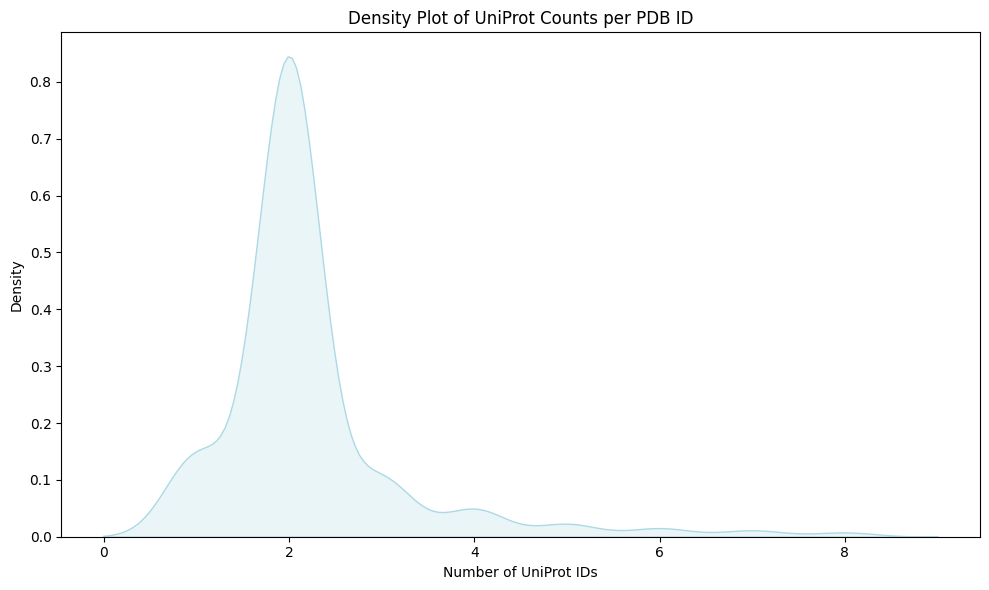

In [ ]:
uniprot_counts_series = pd.Series(uniprot_counts_per_pdb)

plt.figure(figsize=(10, 6))
sns.kdeplot(uniprot_counts_series.values, fill=True, color='lightblue')
plt.title('Density Plot of UniProt Counts per PDB ID')
plt.xlabel('Number of UniProt IDs')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

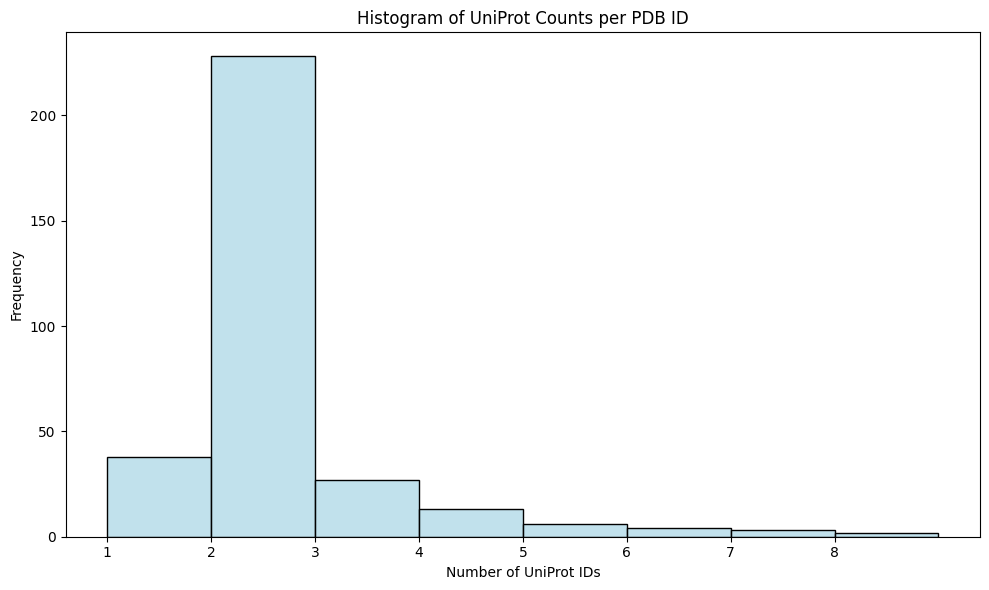

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(uniprot_counts_series.values, bins=range(1, max(uniprot_counts_series.values) + 2), kde=False, color='lightblue', edgecolor='black')
plt.title('Histogram of UniProt Counts per PDB ID')
plt.xlabel('Number of UniProt IDs')
plt.ylabel('Frequency')
plt.xticks(range(1, max(uniprot_counts_series.values) + 1))
plt.tight_layout()
plt.show()

From the plot we see that some PDB IDs have a single Uniprot ID associated:

In [ ]:
min_uniprot_count = min(uniprot_counts_per_pdb.values())
print(f"The minimum number of UniProt IDs associated with a PDB ID is: {min_uniprot_count}")

The minimum number of UniProt IDs associated with a PDB ID is: 1


In [ ]:
max_uniprot_count = max(uniprot_counts_per_pdb.values())
print(f"The maximum number of UniProt IDs associated with a PDB ID is: {max_uniprot_count}")

The maximum number of UniProt IDs associated with a PDB ID is: 8


In [ ]:
prot_per_complex = {} #uniprot_counts_per_pdb

In [ ]:
pdb_1_uniprot = [pdb for pdb, count in uniprot_counts_per_pdb.items() if count == 1]
print(f"Number of PDB IDs with exactly one UniProt ID: {len(pdb_1_uniprot)}")
prot_per_complex[1]=len(pdb_1_uniprot)
pdb_2_uniprot = [pdb for pdb, count in uniprot_counts_per_pdb.items() if count == 2]
print(f"Number of PDB IDs with exactly two UniProt ID: {len(pdb_2_uniprot)}")
prot_per_complex[2]=len(pdb_2_uniprot)
pdb_3_uniprot = [pdb for pdb, count in uniprot_counts_per_pdb.items() if count == 3]
print(f"Number of PDB IDs with exactly three UniProt ID: {len(pdb_3_uniprot)}")
prot_per_complex[3]=len(pdb_3_uniprot)
pdb_4_uniprot = [pdb for pdb, count in uniprot_counts_per_pdb.items() if count == 4]
print(f"Number of PDB IDs with exactly four UniProt ID: {len(pdb_4_uniprot)}")
prot_per_complex[4]=len(pdb_4_uniprot)
pdb_5_uniprot = [pdb for pdb, count in uniprot_counts_per_pdb.items() if count == 5]
print(f"Number of PDB IDs with exactly five UniProt ID: {len(pdb_5_uniprot)}")
prot_per_complex[5]=len(pdb_5_uniprot)
pdb_6_uniprot = [pdb for pdb, count in uniprot_counts_per_pdb.items() if count == 6]
print(f"Number of PDB IDs with exactly six UniProt ID: {len(pdb_6_uniprot)}")
prot_per_complex[6]=len(pdb_6_uniprot)
pdb_7_uniprot = [pdb for pdb, count in uniprot_counts_per_pdb.items() if count == 7]
print(f"Number of PDB IDs with exactly seven UniProt ID: {len(pdb_7_uniprot)}")
prot_per_complex[7]=len(pdb_7_uniprot)
pdb_8_uniprot = [pdb for pdb, count in uniprot_counts_per_pdb.items() if count == 8]
print(f"Number of PDB IDs with exactly eight UniProt ID: {len(pdb_8_uniprot)}")
prot_per_complex[8]=len(pdb_8_uniprot)

Number of PDB IDs with exactly one UniProt ID: 38
Number of PDB IDs with exactly two UniProt ID: 228
Number of PDB IDs with exactly three UniProt ID: 27
Number of PDB IDs with exactly four UniProt ID: 13
Number of PDB IDs with exactly five UniProt ID: 6
Number of PDB IDs with exactly six UniProt ID: 4
Number of PDB IDs with exactly seven UniProt ID: 3
Number of PDB IDs with exactly eight UniProt ID: 2


In [ ]:
print("The dataset counts a total of: "+str(prot_per_complex[1]*1+prot_per_complex[2]*2+prot_per_complex[3]*3+prot_per_complex[4]*4+prot_per_complex[5]*5+prot_per_complex[6]*6+prot_per_complex[7]*7+prot_per_complex[8]*8)+" proteins (or Uniprot IDs)")

The dataset counts a total of: 718 proteins (or Uniprot IDs)
